# $\text{Recherche}$
## $\text{Modèle de prédiction des affluences des parkings}$

In [81]:
# Import des librairies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### Import / traitement des données

              idparc     lastupdate  etatouverture  occupation_rate
count  150688.000000  150688.000000  150688.000000    150688.000000
mean        3.500000      10.993283       0.741187         0.433481
std         2.291295       6.377320       0.437984         0.365184
min         0.000000       0.000000       0.000000         0.000000
25%         1.750000       5.450000       0.000000         0.000000
50%         3.500000      11.016667       1.000000         0.455097
75%         5.250000      16.416667       1.000000         0.781553
max         7.000000      23.983333       1.000000         1.014085
   idparc  lastupdate  etatouverture  occupation_rate
0       0    9.816667              1         0.000000
1       0   10.683333              1         0.000000
2       0   11.300000              1         0.000000
3       0   11.983333              1         0.000000
4       0   12.983333              1         0.066748


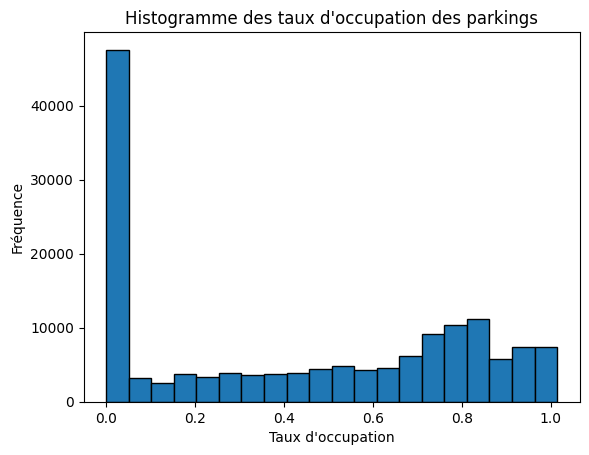

In [ ]:
data_file_path = "data/data.csv"

# Chargement des données
data = pd.read_csv(data_file_path)

# Nettoyage des données
data.dropna(inplace=True)  # Suppression des lignes avec des valeurs manquantes
data.drop_duplicates(inplace=True)  # Suppression des doublons

# Encodage des variables
data['idparc'] = data['idparc'].astype('category').cat.codes # Catégoriser l'id du parc
data['lastupdate'] = pd.to_datetime(data['lastupdate']).dt.hour + pd.to_datetime(data['lastupdate']).dt.minute / 60.0 # Convertir lastupdate en heure de la journée en float
data['etatouverture'] = data['etatouverture'].map({'OUVERT': 1, 'FERME': 0}) # Encoder l'état d'ouverture

# Transformation de capacitesoliste et jrdinfosoliste en pourcentage d'occupation
data['occupation_rate'] = data['jrdinfosoliste'] / data['capacitesoliste']
capacite_soliste = data['capacitesoliste'].values
data.drop(['capacitesoliste', 'jrdinfosoliste'], axis=1, inplace=True)

print(data.describe())
print(data.head())


# Histogramme des taux d'occupation
plt.hist(data['occupation_rate'], bins=20, edgecolor='black')
plt.title('Histogramme des taux d\'occupation des parkings')
plt.xlabel('Taux d\'occupation')
plt.ylabel('Fréquence')
plt.show()

### Séparation des jeux de données

In [83]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=1)

### **Régression Linéaire**

In [ ]:
model = LinearRegression()
model.fit(train_set.drop("occupation_rate", axis=1), train_set["occupation_rate"])
predictions = model.predict(test_set.drop("occupation_rate", axis=1))
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]

y_true = test_set["occupation_rate"].values
y_pred = np.array(predictions)

# Conversion en pourcentage
y_true = y_true*100  
y_pred = y_pred*100

sample = 10
for i in range(sample):
    print(f"Vrai: {y_true[i]:.2f}%, Prédit: {y_pred[i]:.2f}%")

Vrai: 20.63%, Prédit: 56.08%
Vrai: 85.25%, Prédit: 57.94%
Vrai: 73.42%, Prédit: 55.91%
Vrai: 84.99%, Prédit: 58.27%
Vrai: 83.24%, Prédit: 60.75%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 89.69%, Prédit: 58.56%
Vrai: 2.15%, Prédit: 60.85%
Vrai: 18.93%, Prédit: 56.06%
Vrai: 49.09%, Prédit: 60.09%


#### Évaluation

MSE : 671.9653108859284
RMSE : 25.922293704183055
MAE : 19.374251055075618
R² : 0.49484449493911087


C:\Users\theo_\AppData\Local\Temp\ipykernel_19756\3458017945.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = df.groupby("bin")["error"].mean().reset_index()


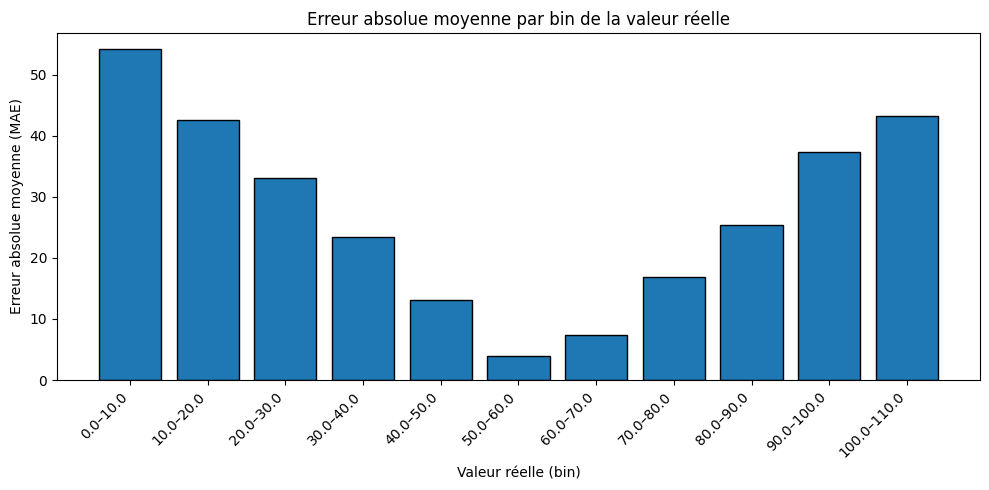

      label     error
   0.0–10.0 54.164684
  10.0–20.0 42.537459
  20.0–30.0 33.113349
  30.0–40.0 23.412286
  40.0–50.0 13.027111
  50.0–60.0  3.873089
  60.0–70.0  7.397170
  70.0–80.0 16.920751
  80.0–90.0 25.344415
 90.0–100.0 37.307048
100.0–110.0 43.241086


In [85]:
# Évaluation des modèles
mse = mean_squared_error(y_true, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(test_set.drop("occupation_rate", axis=1), test_set["occupation_rate"]))

# Histogramme des erreurs absolues moyennes en fonction de la valeur réelle
errors = np.abs(y_true - y_pred)

bin_width = 10
min_val = np.floor(y_true.min() / bin_width) * bin_width
max_val = np.ceil(y_true.max() / bin_width) * bin_width
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Calcul de la MAE par bin
df = pd.DataFrame({
    "y_true": y_true,
    "error": errors
})
df["bin"] = pd.cut(df["y_true"], bins=bins, right=True)

mae_by_bin = df.groupby("bin")["error"].mean().reset_index()

mae_by_bin["label"] = mae_by_bin["bin"].apply(lambda iv: f"{iv.left:.1f}–{iv.right:.1f}") # labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mae_by_bin["label"], mae_by_bin["error"], width=0.8, color="C0", edgecolor="k")
ax.set_xlabel("Valeur réelle (bin)")
ax.set_ylabel("Erreur absolue moyenne (MAE)")
ax.set_title("Erreur absolue moyenne par bin de la valeur réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Affichage optionnel des valeurs numériques
print(mae_by_bin[["label", "error"]].to_string(index=False))